In [2]:
## import requirement
import numpy as np
import scipy
import csv
import matplotlib.pyplot as plt
!python3 -m pip install py3gpp
from py3gpp import *

/home/chatchamon/workarea/npn_5g/bladeRF_txrx/based_IQ_find_NID2/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/chatchamon/workarea/npn_5g/bladeRF_txrx/based_IQ_find_NID2/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


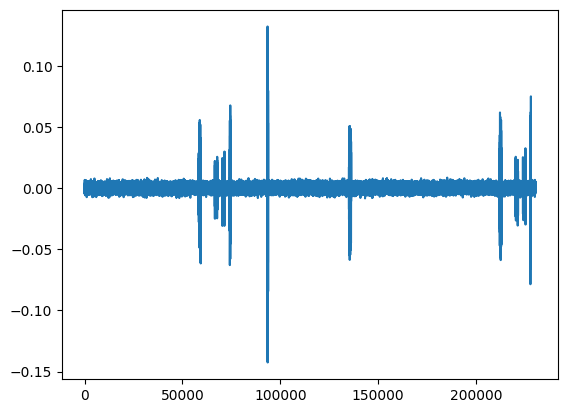

In [4]:
## load rx_srsRAN
input_file = '/home/chatchamon/workarea/IQ_constellation/iq_python/input/fllay_092024/waveform_IQComplex_fllay.csv'
waveform = []
with open(input_file, 'r') as f:
    reader = csv.reader(f)
    for row in reader:
      IQComplex = row[0].strip()
      IQComplex = IQComplex.replace('i','j')
      IQComplex = complex(IQComplex)
      waveform.append(IQComplex)

## initial parameter
sampleRate = 15.36e6
nrbSSB = 20
mu = 1
scs = 15 * 2**mu
# With downsampling
syncNfft = 256                  # minimum FFT Size to cover SS burst
syncSR = syncNfft * scs * 1e3
# for loop
# fshifts = [-15k 0 15k]
fshifts = [-15e3, 0, 15e3]
t = np.arange(len(waveform))/sampleRate

# waveform from SDR
coarseFrequencyOffset = fshifts[1]
rxWaveformFreqCorrected = waveform * np.exp(-1j*2*np.pi*coarseFrequencyOffset*t)
rxWaveformDS = scipy.signal.resample_poly(rxWaveformFreqCorrected, syncSR, sampleRate)